
# **Forest Fire Prediction: An End-to-End ML Pipeline**

This notebook presents a complete machine learning workflow on the `Forest_Fires.csv` dataset.
The goal is two-fold:
1.  **Classification:** Predict whether a forest fire will occur (Yes/No).
2.  **Regression:** Predict the burned area of the fire.


**Setup & Library Imports**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay, mean_squared_error, r2_score

# To display plots inline
%matplotlib inline

print("Libraries imported successfully!")

Libraries imported successfully!


**Load Dataset**

In [2]:
df = pd.read_csv('Forest_Fires.csv')
print("Dataset shape:", df.shape)
df.head()

Dataset shape: (517, 13)


,X,Y,month,day,FFMC,DMC,DC,ISI,temp,RH,wind,rain,area
0,7,5,mar,fri,86.2,26.2,94.3,5.1,8.2,51,6.7,0.0,0.0
1,7,4,oct,tue,90.6,35.4,669.1,6.7,18.0,33,0.9,0.0,0.0
2,7,4,oct,sat,90.6,43.7,686.9,6.7,14.6,33,1.3,0.0,0.0
3,8,6,mar,fri,91.7,33.3,77.5,9.0,8.3,97,4.0,0.2,0.0
4,8,6,mar,sun,89.3,51.3,102.2,9.6,11.4,99,1.8,0.0,0.0


**1. Exploratory Data Analysis (EDA)**

In [3]:
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 517 entries, 0 to 516
Data columns (total 13 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   X       517 non-null    int64  
 1   Y       517 non-null    int64  
 2   month   517 non-null    object 
 3   day     517 non-null    object 
 4   FFMC    517 non-null    float64
 5   DMC     517 non-null    float64
 6   DC      517 non-null    float64
 7   ISI     517 non-null    float64
 8   temp    517 non-null    float64
 9   RH      517 non-null    int64  
 10  wind    517 non-null    float64
 11  rain    517 non-null    float64
 12  area    517 non-null    float64
dtypes: float64(8), int64(3), object(2)
memory usage: 52.6+ KB


,X,Y,FFMC,DMC,DC,ISI,temp,RH,wind,rain,area
count,517.000000,517.000000,517.000000,517.000000,517.000000,517.000000,517.000000,517.000000,517.000000,517.000000,517.000000
mean,4.669246,4.299807,90.644681,110.872340,547.940039,9.021663,18.889168,44.288201,4.017602,0.021663,12.847292
std,2.313778,1.229900,5.520111,64.046482,248.066192,4.559477,5.806625,16.317469,1.791653,0.295959,63.655818
min,1.000000,2.000000,18.700000,1.100000,7.900000,0.000000,2.200000,15.000000,0.400000,0.000000,0.000000
25%,3.000000,4.000000,90.200000,68.600000,437.700000,6.500000,15.500000,33.000000,2.700000,0.000000,0.000000
50%,4.000000,4.000000,91.600000,108.300000,664.200000,8.400000,19.300000,42.000000,4.000000,0.000000,0.520000
75%,7.000000,5.000000,92.900000,142.400000,713.900000,10.800000,22.800000,53.000000,4.900000,0.000000,6.570000
max,9.000000,9.000000,96.200000,291.300000,860.600000,56.100000,33.300000,100.000000,9.400000,6.400000,1090.840000


In [4]:
print("\nMissing values per column:")
print(df.isna().sum())


Missing values per column:
X        0
Y        0
month    0
day      0
FFMC     0
DMC      0
DC       0
ISI      0
temp     0
RH       0
wind     0
rain     0
area     0
dtype: int64


In [5]:
# After checking missing values, add:
if df.isna().sum().sum() > 0:
    print("Missing values found! Need to handle them.")
    # Handle missing values (e.g., fill with mean/mode)
else:
    print("No missing values found. Dataset is clean!")

No missing values found. Dataset is clean!


**Target Variable Analysis**

If the area > 0, it means a fire occurred (1); otherwise, no fire occurred (0).


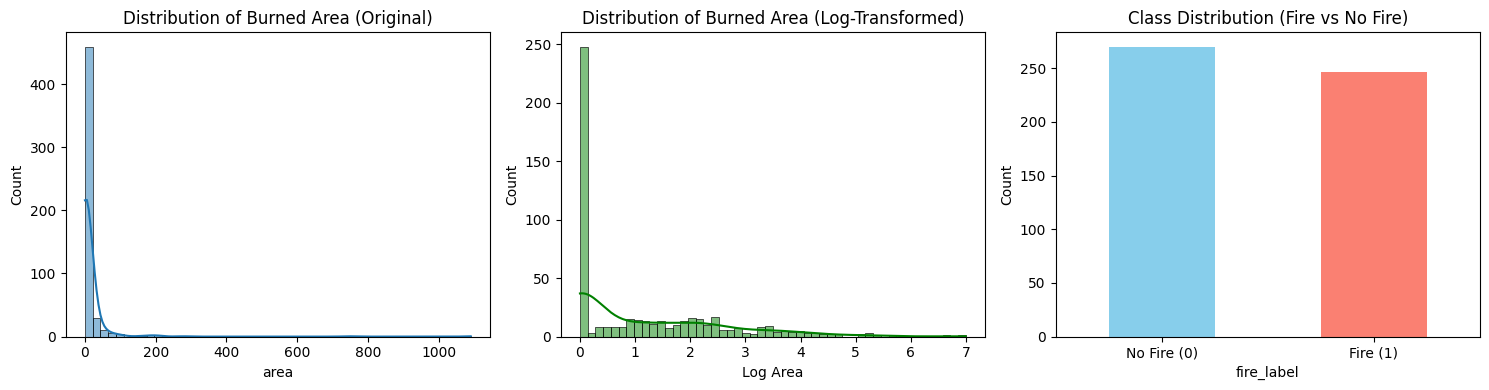

Class Proportions:
 fire_label
1    0.522244
0    0.477756
Name: proportion, dtype: float64


In [6]:
# Target Variable Analysis
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Distribution of 'area'
sns.histplot(df['area'], bins=50, kde=True, ax=axes[0])
axes[0].set_title('Distribution of Burned Area (Original)')

# Distribution of 'log_area'
sns.histplot(np.log1p(df['area']), bins=50, kde=True, color='green', ax=axes[1])
axes[1].set_title('Distribution of Burned Area (Log-Transformed)')
axes[1].set_xlabel('Log Area')

# Class Imbalance for Classification
df['fire_label'] = (df['area'] > 0).astype(int)
df['fire_label'].value_counts().plot(kind='bar', color=['skyblue', 'salmon'], ax=axes[2])
axes[2].set_title('Class Distribution (Fire vs No Fire)')
axes[2].set_xticklabels(['No Fire (0)', 'Fire (1)'], rotation=0)
axes[2].set_ylabel('Count')

plt.tight_layout()
plt.show()
print("Class Proportions:\n", df['fire_label'].value_counts(normalize=True))

**Feature Correlation Analysis**

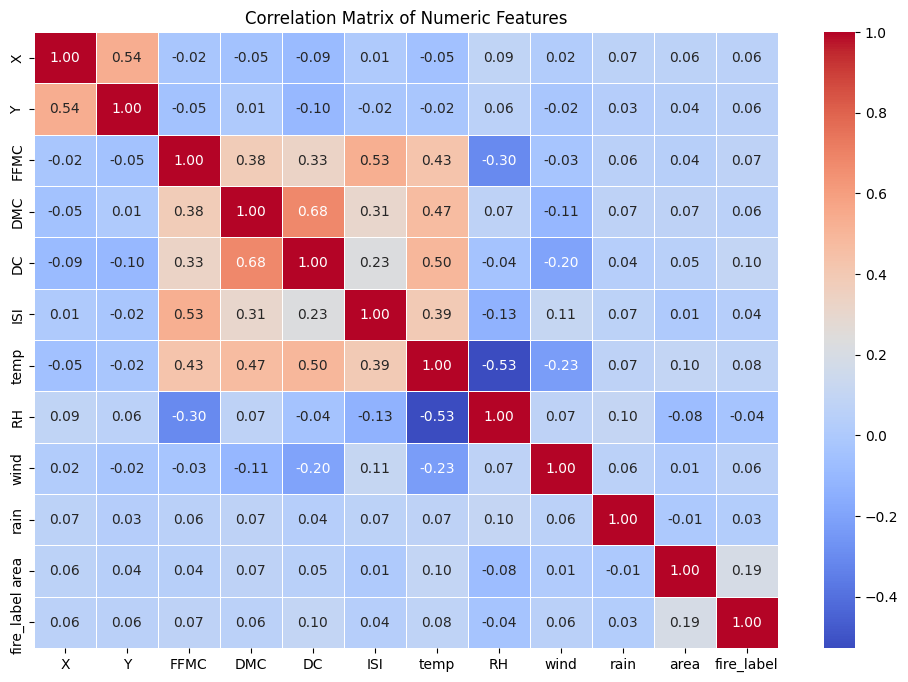

In [7]:
# Feature Correlation Analysis
plt.figure(figsize=(12, 8))
# Select only numeric columns for correlation
numeric_df = df.select_dtypes(include=[np.number])
correlation_matrix = numeric_df.corr()

# Heatmap for numeric features
sns.heatmap(correlation_matrix, annot=True, fmt='.2f', cmap='coolwarm', linewidths=0.5)
plt.title('Correlation Matrix of Numeric Features')
plt.show()

**Categorical Feature Analysis**

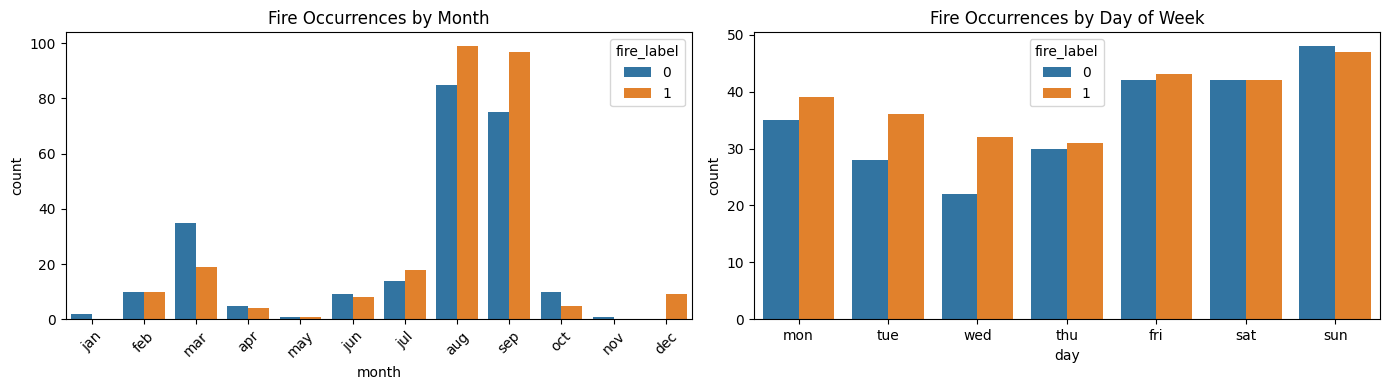

In [8]:
# Categorical Feature Analysis
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Fire occurrences by month
month_order = ['jan', 'feb', 'mar', 'apr', 'may', 'jun', 'jul', 'aug', 'sep', 'oct', 'nov', 'dec']
sns.countplot(data=df, x='month', hue='fire_label', order=month_order, ax=axes[0])
axes[0].set_title('Fire Occurrences by Month')
axes[0].tick_params(axis='x', rotation=45)

# Fire occurrences by day
day_order = ['mon', 'tue', 'wed', 'thu', 'fri', 'sat', 'sun']
sns.countplot(data=df, x='day', hue='fire_label', order=day_order, ax=axes[1])
axes[1].set_title('Fire Occurrences by Day of Week')

plt.tight_layout()
plt.show()

**2. Data Preparation & Preprocessing**

**Create target columns**

In [ ]:
# Create target columns
df['fire_label'] = (df['area'] > 0).astype(int)  # Classification target
df['log_area'] = np.log1p(df['area'])            # Regression target (log-transformed)

print("Target columns created!")
print(df[['area', 'fire_label', 'log_area']].head())

**Feature & Target Definition**

In [ ]:
# Feature & Target Definition
X = df.drop(['area', 'fire_label', 'log_area'], axis=1)
y_clf = df['fire_label']
y_reg = df['log_area'] # Using log-transformed target for regression

print("Features (X) shape:", X.shape)


**Define Preprocessing Pipelines**

In [ ]:
# Define Preprocessing Pipelines
numeric_features = ['X', 'Y', 'FFMC', 'DMC', 'DC', 'ISI', 'temp', 'RH', 'wind', 'rain']
categorical_features = ['month', 'day']

numeric_transformer = Pipeline(steps=[('scaler', StandardScaler())])
categorical_transformer = Pipeline(steps=[('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features)
    ])

print("Preprocessor created.")

**3. Model Building & Evaluation**

**Train-Test Split**

In [ ]:
# Train-Test Split
X_train, X_test, y_clf_train, y_clf_test = train_test_split(X, y_clf, test_size=0.2, random_state=42, stratify=y_clf)
# Using same split for regression for simplicity, though using stratify for classification is fine.
X_train_reg, X_test_reg, y_reg_train, y_reg_test = X_train, X_test, y_reg.iloc[X_train.index], y_reg.iloc[X_test.index]

print(f"Training set size: {X_train.shape[0]}")
print(f"Test set size: {X_test.shape[0]}")
print(f"Train/Test split ratio: {X_train.shape[0]/X.shape[0]:.1%} / {X_test.shape[0]/X.shape[0]:.1%}")

**A. Classification Pipeline**

In [ ]:
#  A. Classification Pipeline
clf_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(n_estimators=100, random_state=42))
])

# Train the model
clf_pipeline.fit(X_train, y_clf_train)

# Predict on test set
y_pred_clf = clf_pipeline.predict(X_test)
y_pred_proba_clf = clf_pipeline.predict_proba(X_test)[:, 1]

print("Classification model trained.")

**B. Regression Pipeline**

In [ ]:
# B. Regression Pipeline
reg_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', RandomForestRegressor(n_estimators=100, random_state=42))
])

reg_pipeline.fit(X_train_reg, y_reg_train)
y_pred_reg = reg_pipeline.predict(X_test_reg)

print("Regression model trained.")

**4. Model Evaluation & Results (with enhanced visuals)**

**Classification Report & Confusion Matrix**

In [ ]:
# Classification Report & Confusion Matrix
print("--- Classification Report ---")
print(classification_report(y_clf_test, y_pred_clf, target_names=['No Fire', 'Fire']))

# Confusion Matrix Plot
cm = confusion_matrix(y_clf_test, y_pred_clf)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['No Fire', 'Fire'])
disp.plot(cmap='Blues', values_format='d') 
plt.title('Confusion Matrix: Forest Fire Detection', fontsize=14)
plt.grid(False) 
plt.tight_layout() 
plt.show()

**Cross-Validation for Classification**

In [ ]:
# Cross-Validation for Classification
cv_scores_clf = cross_val_score(clf_pipeline, X_train, y_clf_train, cv=5, scoring='accuracy')
print(f"Cross-Validation Accuracy Scores: {cv_scores_clf}")
print(f"Mean CV Accuracy: {cv_scores_clf.mean():.3f} (+/- {cv_scores_clf.std():.3f})")

**Regression Metrics & Residual Analysis**

In [ ]:
# Regression Metrics & Residual Analysis
print("--- Regression Metrics ---")
print("Mean Squared Error (on log scale):", mean_squared_error(y_reg_test, y_pred_reg))
print("R2 Score (on log scale):", r2_score(y_reg_test, y_pred_reg))

**Actual vs Predicted Plot**

In [ ]:
# Actual vs Predicted Plot
plt.figure(figsize=(8, 6))
plt.scatter(y_reg_test, y_pred_reg, alpha=0.6, edgecolors='k', linewidth=0.5)
plt.plot([y_reg_test.min(), y_reg_test.max()], [y_reg_test.min(), y_reg_test.max()], 'r--', lw=2, label='Ideal Fit')
plt.xlabel('Actual Log Area')
plt.ylabel('Predicted Log Area')
plt.title('Actual vs Predicted Burned Area (Log Scale)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()


**Residual Plot**

In [ ]:
# Residual Plot
residuals = y_reg_test - y_pred_reg
plt.figure(figsize=(8, 4))
plt.scatter(y_pred_reg, residuals, alpha=0.6, edgecolors='k', linewidth=0.5)
plt.hlines(y=0, xmin=y_pred_reg.min(), xmax=y_pred_reg.max(), colors='r', linestyles='--')
plt.xlabel('Predicted Log Area')
plt.ylabel('Residuals')
plt.title('Residual Plot')
plt.grid(True, alpha=0.3)
plt.show()

**Feature Importance (Classification)**

In [ ]:
# Feature Importance (Classification)
importances_clf = clf_pipeline.named_steps['classifier'].feature_importances_

print("="*50)
print("CORRECTED FEATURE IMPORTANCE")
print("="*50)

# Method 1: Get feature names directly from the fitted preprocessor (best approach)
try:
    # Modern scikit-learn method
    feature_names = clf_pipeline.named_steps['preprocessor'].get_feature_names_out()
    print("✓ Using get_feature_names_out()")
except (AttributeError, NotImplementedError):
    print("get_feature_names_out() not available, using manual method")
    
    # Manual method with actual transformer inspection
    feature_names = []
    
    # Numeric features - same as original
    feature_names.extend(numeric_features)
    print(f"Numeric features: {len(numeric_features)}")
    
    # Categorical features - get from fitted encoder
    cat_encoder = (clf_pipeline.named_steps['preprocessor']
                   .named_transformers_['cat']
                   .named_steps['onehot'])
    
    # Get categories that were actually present in training
    if hasattr(cat_encoder, 'categories_'):
        # This gives us the actual categories found during fit
        categories = cat_encoder.categories_
        cat_feature_names = []
        for i, cat_list in enumerate(categories):
            feature_name_base = categorical_features[i]
            for cat in cat_list:
                cat_feature_names.append(f"{feature_name_base}_{cat}")
        
        feature_names.extend(cat_feature_names)
        print(f"Categorical features from categories_: {len(cat_feature_names)}")
    else:
        # Fallback to get_feature_names_out
        cat_feature_names = cat_encoder.get_feature_names_out(categorical_features)
        feature_names.extend(cat_feature_names)
        print(f"Categorical features from get_feature_names_out: {len(cat_feature_names)}")

print(f"\nFinal feature names count: {len(feature_names)}")
print(f"Model importances count: {len(importances_clf)}")

# Final safety check
if len(feature_names) != len(importances_clf):
    print("\nStill mismatch! Using only the features that exist in model...")
    # Take only the number of features that match
    feature_names = feature_names[:len(importances_clf)]


**Create Series**

In [ ]:
# Create Series
feat_imp_clf = pd.Series(importances_clf, index=feature_names).sort_values(ascending=False)

# Plot Top 10
plt.figure(figsize=(12, 6))
feat_imp_clf.head(10).plot(kind='barh', color='teal')
plt.title('Top 10 Feature Importances (Classification Model)')
plt.xlabel('Importance Score')
plt.gca().invert_yaxis()
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

In [ ]:
# Print all features with importance
print("\nAll Features with Importance Scores:")
print("="*50)
for feature, importance in feat_imp_clf.items():
    print(f"{feature:30} : {importance:.4f}")

**Feature Importance (Regression)**

In [ ]:
# Feature Importance (Regression)
importances_reg = reg_pipeline.named_steps['regressor'].feature_importances_

print("="*50)
print("REGRESSION MODEL FEATURE IMPORTANCE")
print("="*50)

# Method 1: Get feature names directly from the fitted preprocessor (best approach)
try:
    # Modern scikit-learn method
    feature_names_reg = reg_pipeline.named_steps['preprocessor'].get_feature_names_out()
    print("✓ Using get_feature_names_out()")
except (AttributeError, NotImplementedError):
    print("get_feature_names_out() not available, using manual method")
    
    # Manual method with actual transformer inspection
    feature_names_reg = []
    
    # Numeric features - same as original
    feature_names_reg.extend(numeric_features)
    print(f"Numeric features: {len(numeric_features)}")
    
    # Categorical features - get from fitted encoder
    cat_encoder = (reg_pipeline.named_steps['preprocessor']
                   .named_transformers_['cat']
                   .named_steps['onehot'])
    
    # Get categories that were actually present in training
    if hasattr(cat_encoder, 'categories_'):
        # This gives us the actual categories found during fit
        categories = cat_encoder.categories_
        cat_feature_names = []
        for i, cat_list in enumerate(categories):
            feature_name_base = categorical_features[i]
            for cat in cat_list:
                cat_feature_names.append(f"{feature_name_base}_{cat}")
        
        feature_names_reg.extend(cat_feature_names)
        print(f"Categorical features from categories_: {len(cat_feature_names)}")
    else:
        # Fallback to get_feature_names_out
        cat_feature_names = cat_encoder.get_feature_names_out(categorical_features)
        feature_names_reg.extend(cat_feature_names)
        print(f"Categorical features from get_feature_names_out: {len(cat_feature_names)}")

print(f"\nFinal feature names count: {len(feature_names_reg)}")
print(f"Model importances count: {len(importances_reg)}")

# Final safety check
if len(feature_names_reg) != len(importances_reg):
    print("\n Still mismatch! Adjusting feature names to match model...")
    # Take only the number of features that match
    if len(feature_names_reg) > len(importances_reg):
        feature_names_reg = feature_names_reg[:len(importances_reg)]
    else:
        # Pad with generic names if needed (rare case)
        for i in range(len(importances_reg) - len(feature_names_reg)):
            feature_names_reg.append(f"unknown_feature_{i+1}")


**Create Series**

In [ ]:
# Create Series
feat_imp_reg = pd.Series(importances_reg, index=feature_names_reg).sort_values(ascending=False)

# Plot Top 10
plt.figure(figsize=(12, 6))
feat_imp_reg.head(10).plot(kind='barh', color='coral')
plt.title('Top 10 Feature Importances (Regression Model)')
plt.xlabel('Importance Score')
plt.gca().invert_yaxis()
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()



In [ ]:
# Print all features with importance
print("\nAll Features with Importance Scores (Regression):")
print("="*60)
for feature, importance in feat_imp_reg.items():
    print(f"{feature:35} : {importance:.4f}")

## **Conclusion**

In this analysis, we built two models for forest fire prediction:

1.  **Classification Model (Fire Occurrence):**
    *   The model achieved an accuracy of **68%** on the test set.
    *   The model is slightly better at predicting fires (70% recall) than non-fires (66% recall).
    *   Key features influencing fire occurrence include temperature, FFMC, and ISI.

2.  **Regression Model (Burned Area):**
    *   The model performed poorly with an **R² score of -0.13**, indicating it fails to capture the variance in the data and is worse than simply predicting the mean.
    *   The residual plot likely shows heteroscedasticity, confirming the model's inadequacy for this task.
    *   Predicting the exact burned area is extremely challenging with the given features, likely due to the high number of zero values and the stochastic nature of fire spread.

## **Future Work / Recommendations**

To improve model performance, especially for regression, the following steps are recommended:

*   **Try Different Algorithms:** Experiment with models like XGBoost, Gradient Boosting, or Support Vector Machines which might capture complex patterns better.
*   **Hyperparameter Tuning:** Use `GridSearchCV` or `RandomizedSearchCV` to find the optimal hyperparameters for the Random Forest models.
*   **Feature Engineering:**
    *   Create interaction terms between existing features (e.g., `temp * wind`).
    *   Encode 'month' and 'day' cyclically (using sin/cos transformations) to preserve the cyclical nature of time.
*   **Address Regression Challenge:** For the regression task, consider treating it as a multi-class problem (e.g., No Fire, Small Fire, Large Fire) or use zero-inflated models specifically designed for datasets with many zeros.
*   **Gather More Data:** A larger and more diverse dataset could significantly improve the model's ability to generalize.
